In [ ]:
from notebooks.presets import set_cwd
set_cwd()

import numpy as np

from src.embeddings.magnitude_spectrum import (
    spectral_centroid,
    band_energy_ratios,
    magnitude_spectrum
)
from notebooks.evaluations.helpers import (
    apply_embedding_function_shrunk,
    test_embeddings_quality,
    apply_embedding_function_shifts,
    )

In [4]:
data_path = "data/random_sequences/random_sequences.npy"
data = np.load(data_path)
print(data.shape)

(100, 4000)


In [12]:
random_shifts = np.load("notebooks/evaluations/data/random_shifts.npy")
random_shrunks = np.load("notebooks/evaluations/data/random_shrunks.npy")

In [11]:
magnitude_spectrum(data[0], 1)

(array([0.0000e+00, 2.5000e-04, 5.0000e-04, ..., 4.9950e-01, 4.9975e-01,
        5.0000e-01], shape=(2001,)),
 array([2251.58846202,  146.04519265,  218.75666824, ...,   12.84434291,
          15.205852  ,   20.06058631], shape=(2001,)))

In [17]:
bands_i = np.linspace(0, 1, 10)
bands = [(bands_i[i], bands_i[i+1]) for i in range(len(bands_i)-1)]
bands

[(np.float64(0.0), np.float64(0.1111111111111111)),
 (np.float64(0.1111111111111111), np.float64(0.2222222222222222)),
 (np.float64(0.2222222222222222), np.float64(0.3333333333333333)),
 (np.float64(0.3333333333333333), np.float64(0.4444444444444444)),
 (np.float64(0.4444444444444444), np.float64(0.5555555555555556)),
 (np.float64(0.5555555555555556), np.float64(0.6666666666666666)),
 (np.float64(0.6666666666666666), np.float64(0.7777777777777777)),
 (np.float64(0.7777777777777777), np.float64(0.8888888888888888)),
 (np.float64(0.8888888888888888), np.float64(1.0))]

In [18]:
embeddings = apply_embedding_function_shrunk(
    data,
    lambda x : band_energy_ratios(x, 1, bands),
    random_shrunks
    )
embeddings.shape

(100, 6, 9)

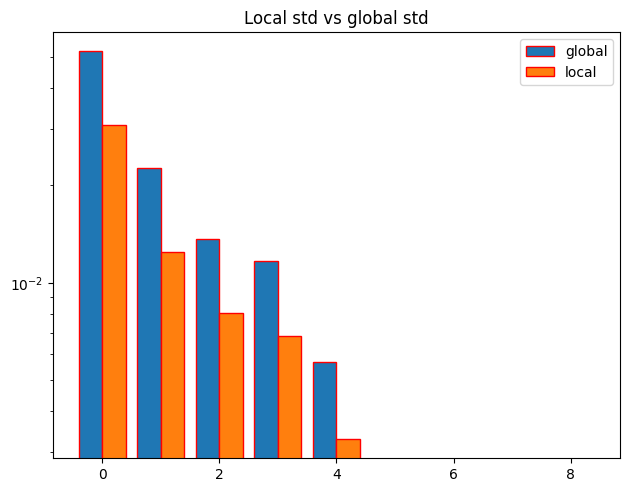

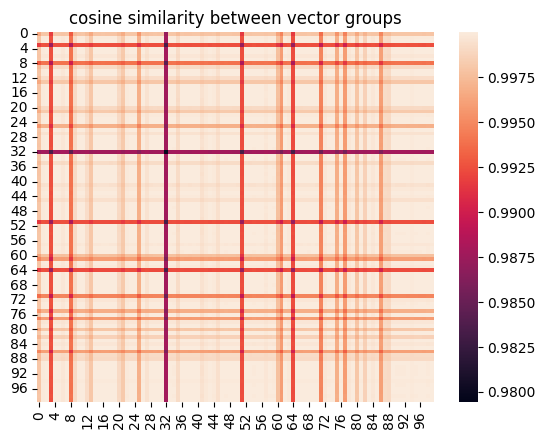

Global cos similarity: 0.9983351915710688, Local cos similarity: 0.998543274024994
Silhouette score cosine: -0.839373667588233
Silhouette score euclidean: -0.7986859329497442
Fisher Discriminant Ratio (FDR): 0.00043040604965019356
Cohen's d: 0.029339599508179846


In [19]:
test_embeddings_quality(embeddings)

In [21]:
embeddings = apply_embedding_function_shifts(
    data,
    lambda x : band_energy_ratios(x, 1, bands),
    random_shifts
    )
embeddings.shape

(100, 6, 9)

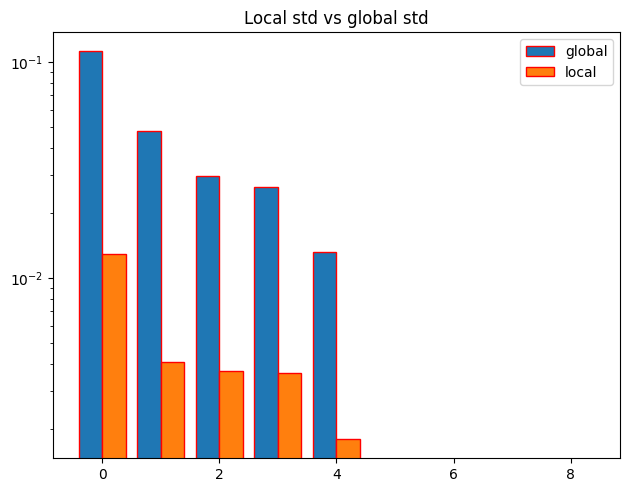

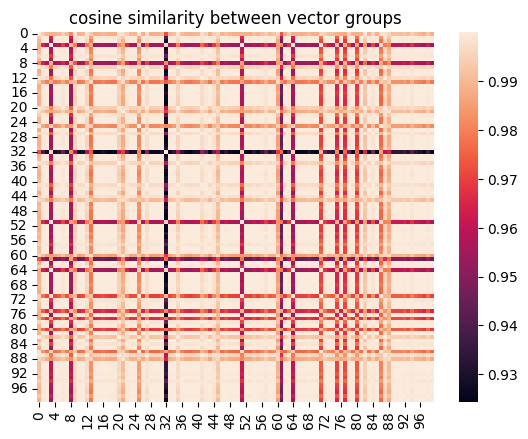

Global cos similarity: 0.9908882702067138, Local cos similarity: 0.9992805257704477
Silhouette score cosine: -0.10225596493739074
Silhouette score euclidean: -0.10571743284238781
Fisher Discriminant Ratio (FDR): 0.22400517701842848
Cohen's d: 0.6693357558332418


In [22]:
test_embeddings_quality(embeddings)